In [1]:
import sys
import os

sys.path.append(os.path.realpath(os.path.join(os.getcwd(), '..', '..', '..', 'T5000', 'T5000-Base', 'Pylians3', 'library')))
sys.path.append(os.path.abspath('../src'))

from pathlib import Path
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils import load_config, radius_graph_pbc_batch
from src.validation import get_tpcf
from src.dataset import deterministic_sample, create_dataloader
from src.prior import scaled_log10_gaussian_mass_prior

import MAS_library as MASL
import Pk_library as PKL

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sample = deterministic_sample("../../Data/subboxes", "../../Data/subboxes",
                             rotations=False, translations=False, cosm_param=None)

In [5]:
train_dl, val_dl, _ = create_dataloader(
    "../../Data/subboxes", "../../Data/subboxes", 
    distributed=False,
    train_kwargs={"batch_size": 1},
    valid_kwargs={"batch_size": 1}
)

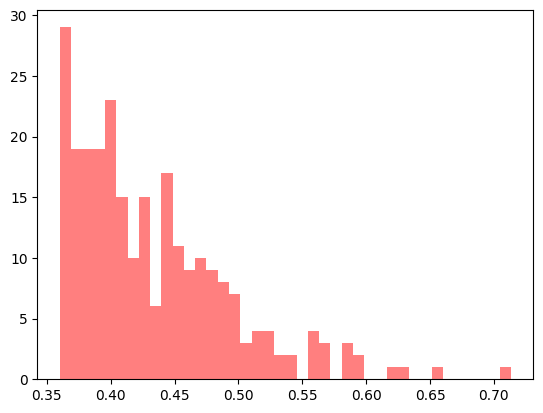

In [39]:
sample = next(iter(train_dl))
masses = sample.mass
mass_priors = scaled_log10_gaussian_mass_prior(masses)

plt.hist(masses, bins=40, color="red", alpha=0.5)
# plt.hist(mass_priors, bins=40, color="blue", alpha=0.5)
plt.show()

In [ ]:
graph = sample.x
batch = torch.zeros(317, dtype=torch.int)
edge_index = radius_graph_pbc_batch(graph, 0.3, batch)

G = nx.Graph()
G.add_edges_from(edge_index.t().cpu().numpy())
if nx.is_connected(G) == True:
    diameter = nx.diameter(G)
    print(f"graph diameter: {diameter}")
else:
    print("Graph is not connected!")
    print(f"Number of components: {nx.number_connected_components(G)}")

In [ ]:
indices = np.linspace(0, 16969, 20, dtype=int)

fig, axes = plt.subplots(4, 5, figsize=(25, 20))

for i, idx in enumerate(indices):
    sample = train_dl.dataset[idx]
    x = sample.x
    batch = torch.zeros(len(x), dtype=torch.long)
    edge_index = radius_graph_pbc_batch(x, 0.3, batch)
    
    G = nx.Graph()
    G.add_edges_from(edge_index.t().cpu().numpy())
    
    if nx.is_connected(G):
        diameter = nx.diameter(G)
        title = f"idx={idx}, n={len(x)}, d={diameter}"
    else:
        nc = nx.number_connected_components(G)
        title = f"idx={idx}, n={len(x)}, DISCONNECTED ({nc})"
    
    ax = axes[i // 5, i % 5]
    pos_dict = {j: (x[j, 0].item(), x[j, 1].item()) for j in range(len(x))}
    nx.draw(G, pos=pos_dict, node_size=3, width=0.15, alpha=0.4, ax=ax)
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.savefig("radius_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
